Shape: (200, 5)
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Missing Values:
 Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Basic Stats:
        Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000 

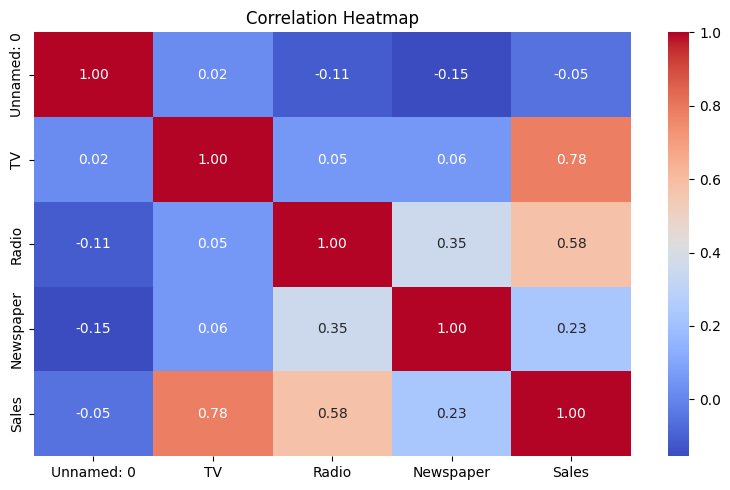

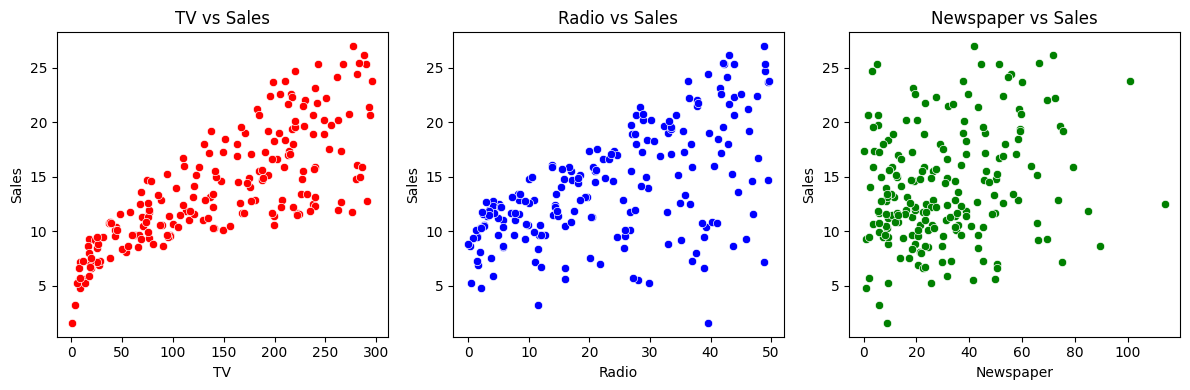

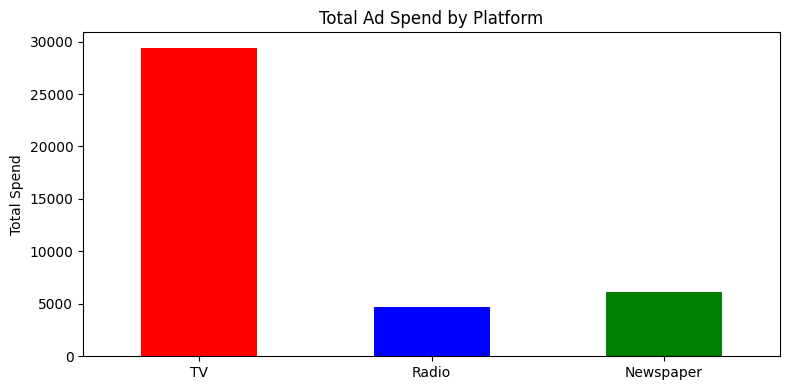


Linear Regression:
R2 Score: 0.8994
MAE: 1.4608
RMSE: 1.7816

Random Forest:
R2 Score: 0.9813
MAE: 0.6201
RMSE: 0.7686


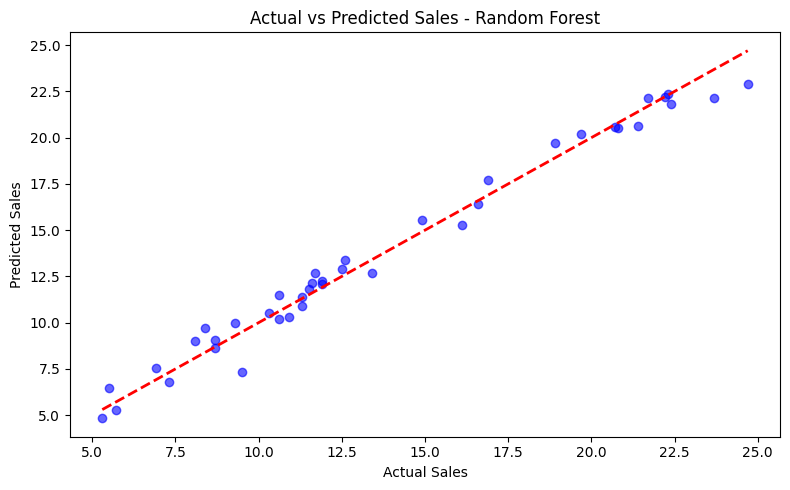

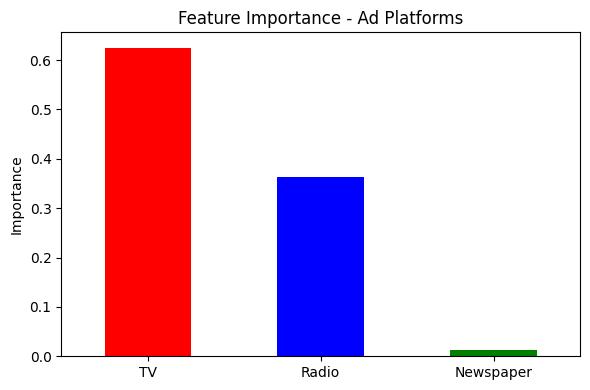


Ad Platform Impact on Sales:
TV           0.624810
Radio        0.362201
Newspaper    0.012989
dtype: float64

TV Coefficient: 0.0447
Radio Coefficient: 0.1892
Newspaper Coefficient: 0.0028

Best Model: Random Forest with R2 = 0.9813


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('Advertising.csv')
print("Shape:", df.shape)
print(df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("sales_heatmap.png")
plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(x='TV', y='Sales', data=df, color='red')
plt.title("TV vs Sales")
plt.subplot(1, 3, 2)
sns.scatterplot(x='Radio', y='Sales', data=df, color='blue')
plt.title("Radio vs Sales")
plt.subplot(1, 3, 3)
sns.scatterplot(x='Newspaper', y='Sales', data=df, color='green')
plt.title("Newspaper vs Sales")
plt.tight_layout()
plt.savefig("ad_vs_sales.png")
plt.show()

plt.figure(figsize=(8, 4))
df[['TV', 'Radio', 'Newspaper']].sum().plot(kind='bar', color=['red', 'blue', 'green'])
plt.title("Total Ad Spend by Platform")
plt.ylabel("Total Spend")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("ad_spend.png")
plt.show()

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("\nLinear Regression:")
print("R2 Score:", round(r2_score(y_test, lr_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, lr_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, lr_pred)), 4))

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("\nRandom Forest:")
print("R2 Score:", round(r2_score(y_test, rf_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, rf_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_pred)), 4))

plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title("Actual vs Predicted Sales - Random Forest")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6, 4))
feat_imp.plot(kind='bar', color=['red', 'blue', 'green'])
plt.title("Feature Importance - Ad Platforms")
plt.ylabel("Importance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

print("\nAd Platform Impact on Sales:")
print(feat_imp)
print("\nTV Coefficient:", round(lr.coef_[0], 4))
print("Radio Coefficient:", round(lr.coef_[1], 4))
print("Newspaper Coefficient:", round(lr.coef_[2], 4))
print("\nBest Model: Random Forest with R2 =", round(r2_score(y_test, rf_pred), 4))


In [2]:
from google.colab import files
uploaded=files.upload()


Saving Advertising.csv to Advertising.csv
